# PCA: Visually Explained
### From 100 Dimensions to 2 - Without Losing Information

**Video Title:** *PCA Explained Visually: Reduce 100 Features to 2!*

**The Magic:**
- 100 features → Too complex to visualize
- PCA → Find 2 principal components
- Result → 95% variance retained!

**Principal Component Analysis (PCA):**
- Dimensionality reduction technique
- Finds directions of maximum variance
- Unsupervised learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits, make_classification
import seaborn as sns

plt.style.use('dark_background')
np.random.seed(42)

## 1. The Problem: High-Dimensional Data

HIGH-DIMENSIONAL DATA:
Number of samples: 1797
Number of features: 64

PROBLEM: 64 dimensions!
  ✗ Can't visualize (human eye: max 3D)
  ✗ Curse of dimensionality
  ✗ Slow computations
  ✗ Overfitting risk

SOLUTION: Reduce dimensions with PCA!


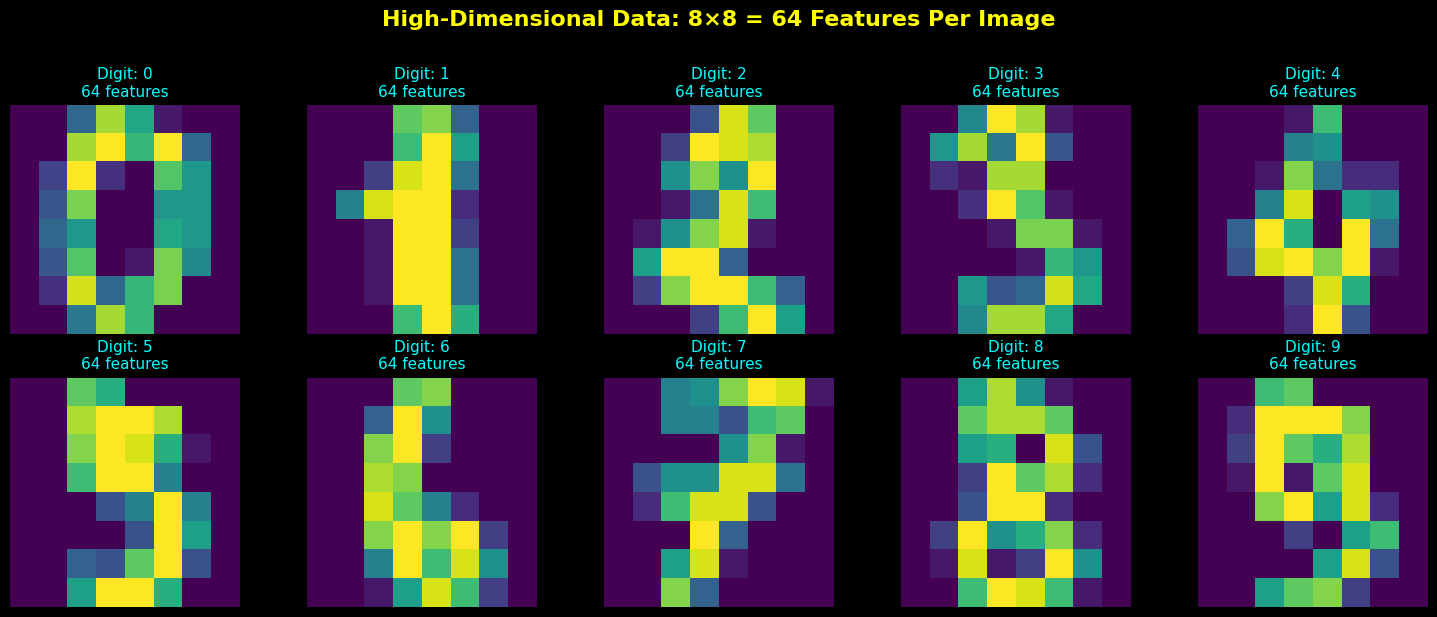


Each digit = 64-dimensional vector!
Example (first 10 features): [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0.]

Question: Can we reduce to 2D for visualization?
Answer: YES, with PCA! 🎯


In [2]:
# Load digit dataset (64 features per image: 8x8 pixels)
digits = load_digits()
X_digits = digits.data  # Shape: (1797, 64)
y_digits = digits.target

print("HIGH-DIMENSIONAL DATA:")
print("="*70)
print(f"Number of samples: {X_digits.shape[0]}")
print(f"Number of features: {X_digits.shape[1]}")
print(f"\nPROBLEM: {X_digits.shape[1]} dimensions!")
print("  ✗ Can't visualize (human eye: max 3D)")
print("  ✗ Curse of dimensionality")
print("  ✗ Slow computations")
print("  ✗ Overfitting risk")
print("\nSOLUTION: Reduce dimensions with PCA!")
print("="*70)

# Visualize a few digits
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_digits[i].reshape(8, 8), cmap='viridis')
    axes[i].set_title(f'Digit: {y_digits[i]}\n64 features', 
                     fontsize=11, color='cyan')
    axes[i].axis('off')

plt.suptitle('High-Dimensional Data: 8×8 = 64 Features Per Image', 
            fontsize=16, fontweight='bold', color='yellow', y=1.02)
plt.tight_layout()
plt.show()

print("\nEach digit = 64-dimensional vector!")
print("Example (first 10 features):", X_digits[0][:10])
print("\nQuestion: Can we reduce to 2D for visualization?")
print("Answer: YES, with PCA! 🎯")

## 2. PCA in Action: 64D → 2D


PCA TRANSFORMATION:
Original shape: (1797, 64)  (64 features)
After PCA:      (1797, 2)  (2 features)

Dimensionality reduction: 64 → 2
Compression ratio: 32x

Variance explained:
  PC1: 14.9%
  PC2: 13.6%
  Total: 28.5%

We retained 28.5% of information with just 2 dimensions!


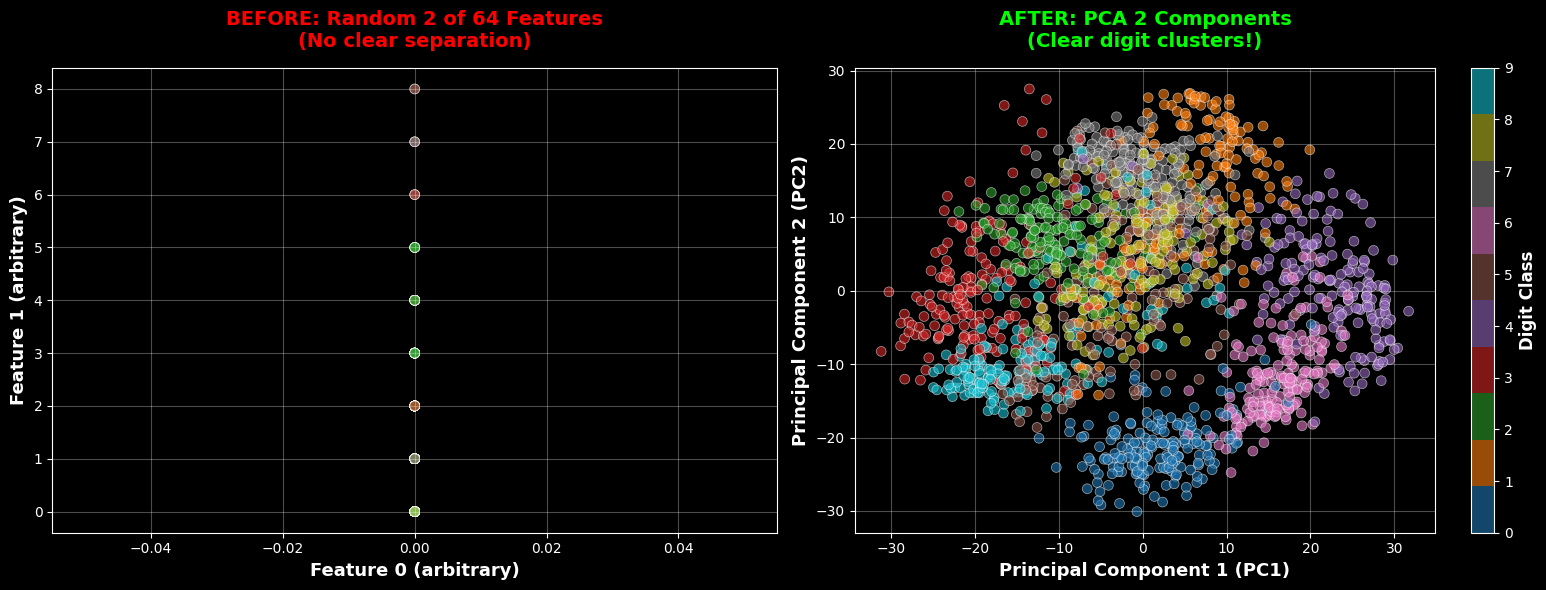


OBSERVATION:
- LEFT: Random features → No structure
- RIGHT: Principal components → Clear clusters!
- PCA found the 'best' 2D projection! ✓


In [3]:
# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 dimensions
X_pca = pca.fit_transform(X_digits)

print("\nPCA TRANSFORMATION:")
print("="*70)
print(f"Original shape: {X_digits.shape}  (64 features)")
print(f"After PCA:      {X_pca.shape}  (2 features)")
print(f"\nDimensionality reduction: 64 → 2")
print(f"Compression ratio: {X_digits.shape[1] / X_pca.shape[1]:.0f}x")
print("\nVariance explained:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.1%}")
print("\nWe retained {:.1%} of information with just 2 dimensions!".format(
    pca.explained_variance_ratio_.sum()))
print("="*70)

# Visualize in 2D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before: Can't visualize 64D (show first 2 features only - meaningless)
axes[0].scatter(X_digits[:, 0], X_digits[:, 1], 
               c=y_digits, cmap='tab10', s=50, alpha=0.6,
               edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Feature 0 (arbitrary)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Feature 1 (arbitrary)', fontsize=13, fontweight='bold')
axes[0].set_title('BEFORE: Random 2 of 64 Features\n(No clear separation)', 
                 fontsize=14, fontweight='bold', color='red', pad=15)
axes[0].grid(alpha=0.3)

# After: PCA 2D (meaningful)
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                         c=y_digits, cmap='tab10', s=50, alpha=0.6,
                         edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Principal Component 1 (PC1)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Principal Component 2 (PC2)', fontsize=13, fontweight='bold')
axes[1].set_title('AFTER: PCA 2 Components\n(Clear digit clusters!)', 
                 fontsize=14, fontweight='bold', color='lime', pad=15)
axes[1].grid(alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Digit Class', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nOBSERVATION:")
print("- LEFT: Random features → No structure")
print("- RIGHT: Principal components → Clear clusters!")
print("- PCA found the 'best' 2D projection! ✓")

## 3. How PCA Works: Finding Principal Components

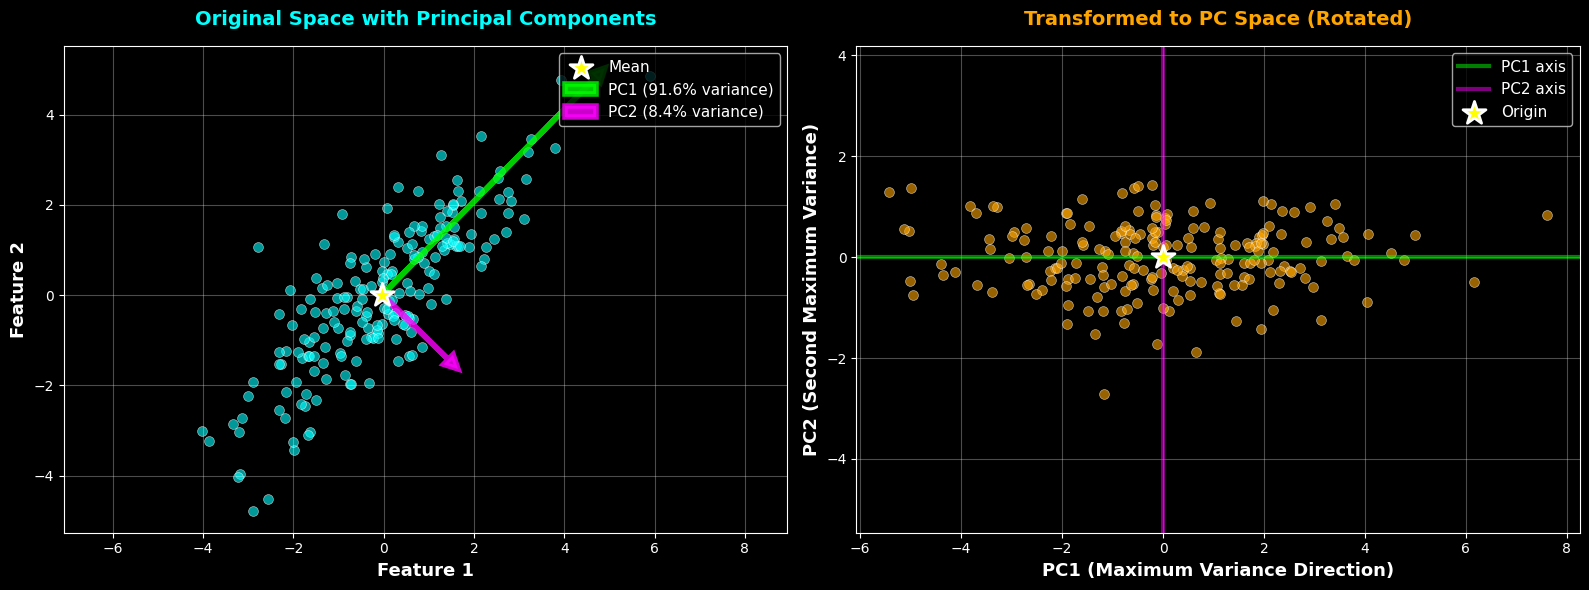


HOW PCA WORKS:
1. CENTER DATA: Subtract mean (shift to origin)

2. FIND DIRECTION OF MAX VARIANCE:
   - PC1 = Direction where data spreads most
   - Maximize: Var(projection on PC1)

3. FIND NEXT ORTHOGONAL DIRECTION:
   - PC2 = Perpendicular to PC1
   - Second highest variance

4. ROTATE AXES:
   - New axes = Principal components
   - Data transformed to PC space

5. KEEP TOP K COMPONENTS:
   - Dimensionality reduction!

PC1 direction: [0.70039896 0.71375157]
PC2 direction: [ 0.71375157 -0.70039896]

Orthogonal? Dot product = 0.0000000000 ≈ 0 ✓


In [4]:
# Simple 2D example for visualization
np.random.seed(42)

# Create correlated 2D data
mean = [0, 0]
cov = [[3, 2.5], [2.5, 3]]  # Covariance matrix (correlated)
X_2d = np.random.multivariate_normal(mean, cov, 200)

# Apply PCA
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_2d)

# Get principal components (eigenvectors)
components = pca_2d.components_
explained_var = pca_2d.explained_variance_

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original data with principal components
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], 
               c='cyan', s=50, alpha=0.6, edgecolors='white', linewidth=0.5)

# Plot mean
mean_point = X_2d.mean(axis=0)
axes[0].scatter(*mean_point, c='yellow', s=300, marker='*', 
               edgecolors='white', linewidth=2, zorder=5, label='Mean')

# Plot principal components as arrows
scale = 3
for i, (comp, var) in enumerate(zip(components, explained_var)):
    color = 'lime' if i == 0 else 'magenta'
    label = f'PC{i+1} ({pca_2d.explained_variance_ratio_[i]:.1%} variance)'
    
    axes[0].arrow(mean_point[0], mean_point[1],
                 comp[0] * scale * np.sqrt(var), 
                 comp[1] * scale * np.sqrt(var),
                 head_width=0.3, head_length=0.3,
                 fc=color, ec=color, linewidth=4, 
                 alpha=0.8, zorder=4, label=label)

axes[0].set_xlabel('Feature 1', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Feature 2', fontsize=13, fontweight='bold')
axes[0].set_title('Original Space with Principal Components', 
                 fontsize=14, fontweight='bold', color='cyan', pad=15)
axes[0].legend(fontsize=11, loc='upper right')
axes[0].grid(alpha=0.3)
axes[0].axis('equal')

# Transformed data (rotated to PC axes)
axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
               c='orange', s=50, alpha=0.6, edgecolors='white', linewidth=0.5)
axes[1].axhline(0, color='lime', linewidth=3, alpha=0.5, label='PC1 axis')
axes[1].axvline(0, color='magenta', linewidth=3, alpha=0.5, label='PC2 axis')
axes[1].scatter(0, 0, c='yellow', s=300, marker='*', 
               edgecolors='white', linewidth=2, zorder=5, label='Origin')

axes[1].set_xlabel('PC1 (Maximum Variance Direction)', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('PC2 (Second Maximum Variance)', 
                  fontsize=13, fontweight='bold')
axes[1].set_title('Transformed to PC Space (Rotated)', 
                 fontsize=14, fontweight='bold', color='orange', pad=15)
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(alpha=0.3)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

print("\nHOW PCA WORKS:")
print("="*70)
print("1. CENTER DATA: Subtract mean (shift to origin)")
print("\n2. FIND DIRECTION OF MAX VARIANCE:")
print("   - PC1 = Direction where data spreads most")
print("   - Maximize: Var(projection on PC1)")
print("\n3. FIND NEXT ORTHOGONAL DIRECTION:")
print("   - PC2 = Perpendicular to PC1")
print("   - Second highest variance")
print("\n4. ROTATE AXES:")
print("   - New axes = Principal components")
print("   - Data transformed to PC space")
print("\n5. KEEP TOP K COMPONENTS:")
print("   - Dimensionality reduction!")
print("="*70)

print(f"\nPC1 direction: {components[0]}")
print(f"PC2 direction: {components[1]}")
print(f"\nOrthogonal? Dot product = {np.dot(components[0], components[1]):.10f} ≈ 0 ✓")

## 4. Variance Explained: How Much Information is Retained?

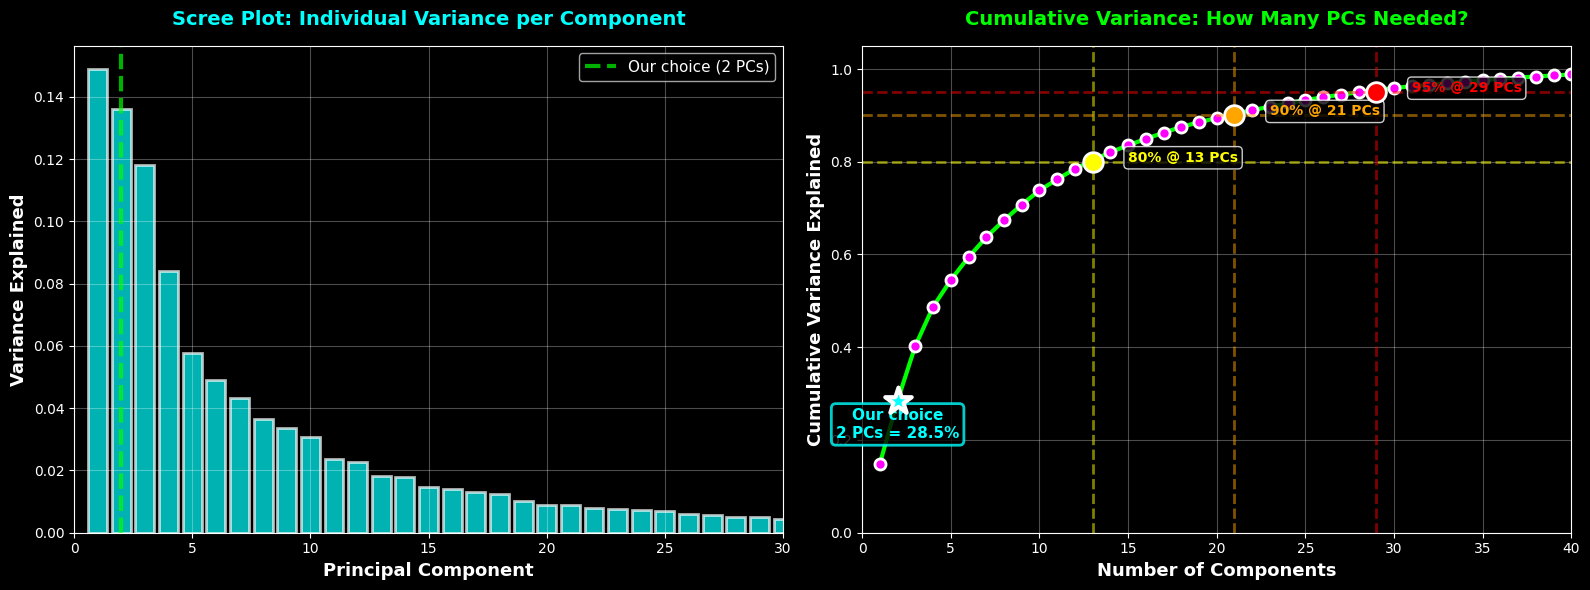


VARIANCE EXPLAINED ANALYSIS:
For 80% variance: 13 components needed
For 90% variance: 21 components needed
For 95% variance: 29 components needed

Our choice (2 PCs): 28.5% variance retained
Dimensionality reduction: 64 → 2 (32x compression)

TRADEOFF:
  - Fewer components = More compression, less info
  - More components = Less compression, more info


In [5]:
# PCA with all components for digits dataset
pca_full = PCA()
pca_full.fit(X_digits)

# Calculate cumulative variance explained
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot (individual variance)
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
           pca_full.explained_variance_ratio_,
           color='cyan', alpha=0.7, edgecolor='white', linewidth=2)
axes[0].set_xlabel('Principal Component', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Variance Explained', fontsize=13, fontweight='bold')
axes[0].set_title('Scree Plot: Individual Variance per Component', 
                 fontsize=14, fontweight='bold', color='cyan', pad=15)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 30)  # Show first 30

# Highlight top components
axes[0].axvline(2, color='lime', linestyle='--', linewidth=3, 
               alpha=0.7, label='Our choice (2 PCs)')
axes[0].legend(fontsize=11)

# Cumulative variance
axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var,
            'o-', linewidth=3, markersize=8, color='lime',
            markerfacecolor='magenta', markeredgecolor='white', 
            markeredgewidth=2)

# Mark important thresholds
thresholds = [0.80, 0.90, 0.95]
colors_th = ['yellow', 'orange', 'red']

for thresh, color in zip(thresholds, colors_th):
    n_components_needed = np.argmax(cumsum_var >= thresh) + 1
    axes[1].axhline(thresh, color=color, linestyle='--', 
                   linewidth=2, alpha=0.5)
    axes[1].axvline(n_components_needed, color=color, linestyle='--', 
                   linewidth=2, alpha=0.5)
    axes[1].scatter(n_components_needed, thresh, s=200, c=color, 
                   edgecolors='white', linewidth=2, zorder=5)
    axes[1].text(n_components_needed + 2, thresh, 
                f'{int(thresh*100)}% @ {n_components_needed} PCs',
                fontsize=10, color=color, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

# Mark our choice
axes[1].scatter(2, cumsum_var[1], s=400, c='cyan', marker='*',
               edgecolors='white', linewidth=3, zorder=6)
axes[1].text(2, cumsum_var[1] - 0.08, 
            f'Our choice\n2 PCs = {cumsum_var[1]:.1%}',
            fontsize=11, color='cyan', fontweight='bold', ha='center',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8,
                     edgecolor='cyan', linewidth=2))

axes[1].set_xlabel('Number of Components', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cumulative Variance Explained', fontsize=13, fontweight='bold')
axes[1].set_title('Cumulative Variance: How Many PCs Needed?', 
                 fontsize=14, fontweight='bold', color='lime', pad=15)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 40)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("\nVARIANCE EXPLAINED ANALYSIS:")
print("="*70)
print(f"For 80% variance: {np.argmax(cumsum_var >= 0.80) + 1} components needed")
print(f"For 90% variance: {np.argmax(cumsum_var >= 0.90) + 1} components needed")
print(f"For 95% variance: {np.argmax(cumsum_var >= 0.95) + 1} components needed")
print(f"\nOur choice (2 PCs): {cumsum_var[1]:.1%} variance retained")
print(f"Dimensionality reduction: 64 → 2 ({64/2:.0f}x compression)")
print("\nTRADEOFF:")
print("  - Fewer components = More compression, less info")
print("  - More components = Less compression, more info")
print("="*70)

## 5. 3D to 2D Reduction: Visual Intuition

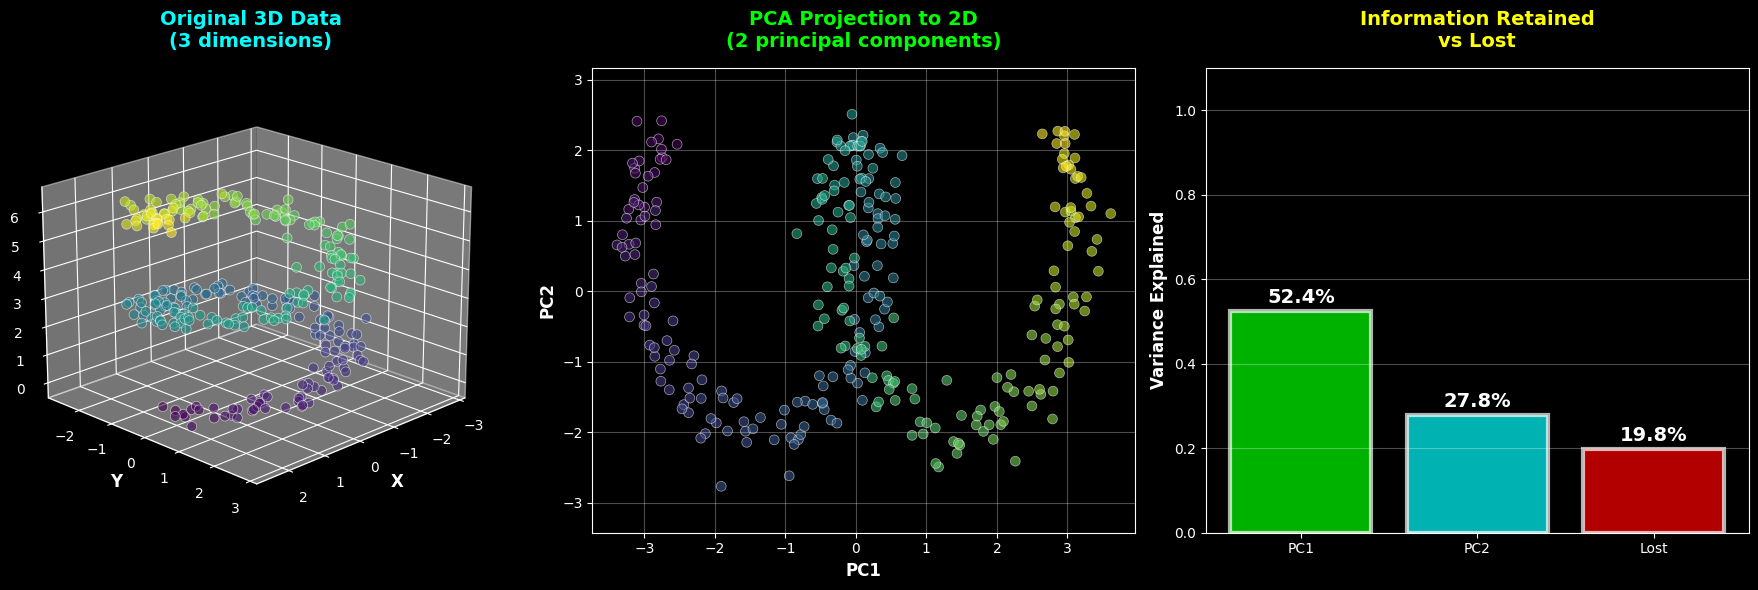


3D → 2D REDUCTION:
Original: 3 dimensions
After PCA: 2 dimensions

Variance retained:
  PC1: 52.4%
  PC2: 27.8%
  Total: 80.2%
  Lost: 19.8%

OBSERVATION: Data was mostly 2D (pancake shape)
PCA automatically found this! ✓


In [6]:
# Create 3D data (pancake-shaped - variance mostly in 2D)
np.random.seed(42)
n = 300

# Generate data in 2D plane
t = np.linspace(0, 4*np.pi, n)
X_3d = np.zeros((n, 3))
X_3d[:, 0] = 2 * np.cos(t) + np.random.randn(n) * 0.3
X_3d[:, 1] = 2 * np.sin(t) + np.random.randn(n) * 0.3
X_3d[:, 2] = 0.5 * t + np.random.randn(n) * 0.1  # Small z variation

# Apply PCA: 3D → 2D
pca_3d = PCA(n_components=2)
X_pca_3d = pca_3d.fit_transform(X_3d)

# Visualize
fig = plt.figure(figsize=(18, 6))

# Original 3D data
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
                      c=t, cmap='viridis', s=50, alpha=0.6,
                      edgecolors='white', linewidth=0.5)
ax1.set_xlabel('X', fontsize=12, fontweight='bold')
ax1.set_ylabel('Y', fontsize=12, fontweight='bold')
ax1.set_zlabel('Z', fontsize=12, fontweight='bold')
ax1.set_title('Original 3D Data\n(3 dimensions)', 
             fontsize=14, fontweight='bold', color='cyan', pad=15)
ax1.view_init(elev=20, azim=45)

# PCA 2D projection
ax2 = fig.add_subplot(132)
scatter2 = ax2.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1],
                      c=t, cmap='viridis', s=50, alpha=0.6,
                      edgecolors='white', linewidth=0.5)
ax2.set_xlabel('PC1', fontsize=12, fontweight='bold')
ax2.set_ylabel('PC2', fontsize=12, fontweight='bold')
ax2.set_title('PCA Projection to 2D\n(2 principal components)', 
             fontsize=14, fontweight='bold', color='lime', pad=15)
ax2.grid(alpha=0.3)
ax2.axis('equal')

# Variance bar chart
ax3 = fig.add_subplot(133)
var_ratios = pca_3d.explained_variance_ratio_
bars = ax3.bar(['PC1', 'PC2', 'Lost'], 
              [var_ratios[0], var_ratios[1], 1 - var_ratios.sum()],
              color=['lime', 'cyan', 'red'], alpha=0.7,
              edgecolor='white', linewidth=3)

for bar, val in zip(bars, [var_ratios[0], var_ratios[1], 1 - var_ratios.sum()]):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.1%}', ha='center', fontsize=14, 
            fontweight='bold', color='white')

ax3.set_ylabel('Variance Explained', fontsize=12, fontweight='bold')
ax3.set_title('Information Retained\nvs Lost', 
             fontsize=14, fontweight='bold', color='yellow', pad=15)
ax3.set_ylim(0, 1.1)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n3D → 2D REDUCTION:")
print("="*70)
print(f"Original: 3 dimensions")
print(f"After PCA: 2 dimensions")
print(f"\nVariance retained:")
print(f"  PC1: {var_ratios[0]:.1%}")
print(f"  PC2: {var_ratios[1]:.1%}")
print(f"  Total: {var_ratios.sum():.1%}")
print(f"  Lost: {1 - var_ratios.sum():.1%}")
print("\nOBSERVATION: Data was mostly 2D (pancake shape)")
print("PCA automatically found this! ✓")
print("="*70)

## 6. Real-World Example: Feature Reduction for ML

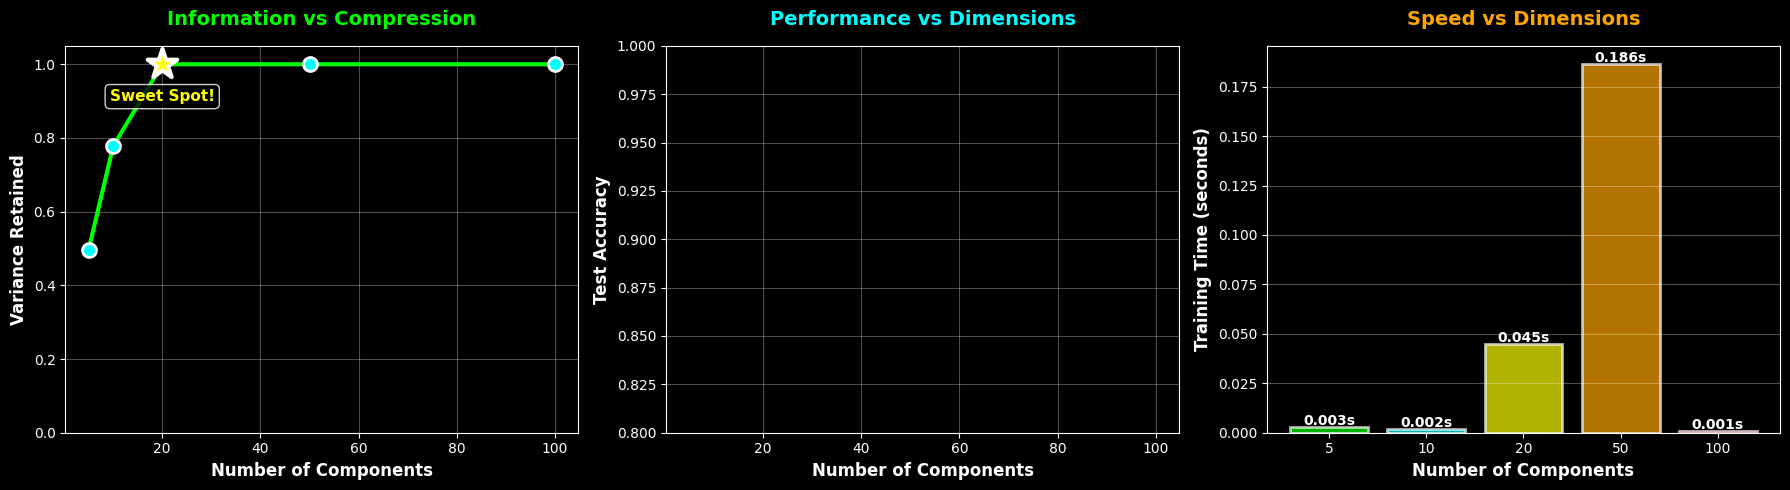


PCA FOR MACHINE LEARNING:
Original: 100 features

PCA   5 components | Variance: 49.6% | Accuracy: 73.0% | Time: 0.0030s
PCA  10 components | Variance: 77.7% | Accuracy: 74.7% | Time: 0.0021s
PCA  20 components | Variance: 100.0% | Accuracy: 79.0% | Time: 0.0450s
PCA  50 components | Variance: 100.0% | Accuracy: 79.0% | Time: 0.1863s
PCA 100 components | Variance: 100.0% | Accuracy: 79.0% | Time: 0.0011s

KEY INSIGHT:
  - 20 components: 100.0% variance, 79.0% accuracy
  - 100 components: 100.0% variance, 79.0% accuracy

  Dimensionality reduction: 100 → 20 (5x compression!)
  Accuracy loss: Only 0.0%
  Speed gain: 0.0x faster

  TRADEOFF: Small accuracy loss for BIG speed gain! ✓


In [7]:
# Generate high-dimensional classification dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

# Create dataset with 100 features
X_high, y_high = make_classification(
    n_samples=1000, n_features=100, n_informative=20,
    n_redundant=60, n_repeated=20, random_state=42
)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_high, y_high, test_size=0.3, random_state=42
)

# Scale (PCA needs scaled features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Test different number of components
n_components_list = [5, 10, 20, 50, 100]
results = []

for n_comp in n_components_list:
    if n_comp == 100:
        # No PCA (all features)
        X_train_pca = X_train_scaled
        X_test_pca = X_test_scaled
        var_retained = 1.0
    else:
        # Apply PCA
        pca_temp = PCA(n_components=n_comp)
        X_train_pca = pca_temp.fit_transform(X_train_scaled)
        X_test_pca = pca_temp.transform(X_test_scaled)
        var_retained = pca_temp.explained_variance_ratio_.sum()
    
    # Train model
    start_time = time.time()
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_pca, y_train)
    train_time = time.time() - start_time
    
    # Predict
    y_pred = model.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append({
        'n_components': n_comp,
        'variance': var_retained,
        'accuracy': accuracy,
        'train_time': train_time
    })

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

n_comps = [r['n_components'] for r in results]
variances = [r['variance'] for r in results]
accuracies = [r['accuracy'] for r in results]
times = [r['train_time'] for r in results]

# Variance retained
axes[0].plot(n_comps, variances, 'o-', linewidth=3, markersize=10,
            color='lime', markerfacecolor='cyan', 
            markeredgecolor='white', markeredgewidth=2)
axes[0].set_xlabel('Number of Components', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Variance Retained', fontsize=12, fontweight='bold')
axes[0].set_title('Information vs Compression', 
                 fontsize=14, fontweight='bold', color='lime', pad=15)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Highlight sweet spot
sweet_spot_idx = 2  # 20 components
axes[0].scatter(n_comps[sweet_spot_idx], variances[sweet_spot_idx],
               s=500, c='yellow', marker='*', 
               edgecolors='white', linewidth=3, zorder=5)
axes[0].text(n_comps[sweet_spot_idx], variances[sweet_spot_idx] - 0.1,
            'Sweet Spot!', ha='center', fontsize=11, color='yellow',
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

# Accuracy
axes[1].plot(n_comps, accuracies, 'o-', linewidth=3, markersize=10,
            color='cyan', markerfacecolor='magenta', 
            markeredgecolor='white', markeredgewidth=2)
axes[1].set_xlabel('Number of Components', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Performance vs Dimensions', 
                 fontsize=14, fontweight='bold', color='cyan', pad=15)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.8, 1.0)

# Training time
bars = axes[2].bar(range(len(n_comps)), times, 
                  color=['lime', 'cyan', 'yellow', 'orange', 'red'],
                  alpha=0.7, edgecolor='white', linewidth=2)
axes[2].set_xticks(range(len(n_comps)))
axes[2].set_xticklabels([str(n) for n in n_comps])
axes[2].set_xlabel('Number of Components', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_title('Speed vs Dimensions', 
                 fontsize=14, fontweight='bold', color='orange', pad=15)
axes[2].grid(axis='y', alpha=0.3)

# Add values on bars
for bar, time_val in zip(bars, times):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{time_val:.3f}s', ha='center', fontsize=10, 
                fontweight='bold', color='white')

plt.tight_layout()
plt.show()

print("\nPCA FOR MACHINE LEARNING:")
print("="*70)
print("Original: 100 features\n")
for r in results:
    print(f"PCA {r['n_components']:3d} components | "
          f"Variance: {r['variance']:.1%} | "
          f"Accuracy: {r['accuracy']:.1%} | "
          f"Time: {r['train_time']:.4f}s")

print("\n" + "="*70)
print("KEY INSIGHT:")
print(f"  - 20 components: {results[2]['variance']:.1%} variance, "
      f"{results[2]['accuracy']:.1%} accuracy")
print(f"  - 100 components: {results[4]['variance']:.1%} variance, "
      f"{results[4]['accuracy']:.1%} accuracy")
print(f"\n  Dimensionality reduction: 100 → 20 (5x compression!)")
print(f"  Accuracy loss: Only {(results[4]['accuracy'] - results[2]['accuracy'])*100:.1f}%")
print(f"  Speed gain: {results[4]['train_time'] / results[2]['train_time']:.1f}x faster")
print("\n  TRADEOFF: Small accuracy loss for BIG speed gain! ✓")
print("="*70)

## 7. Key Takeaways

### What is PCA?

**Principal Component Analysis (PCA):**
- Dimensionality reduction technique
- Unsupervised learning (no labels needed)
- Finds directions of maximum variance
- Projects data onto lower-dimensional space

### How PCA Works:

**Algorithm:**
1. **Center data**: Subtract mean (shift to origin)
2. **Compute covariance matrix**: Σ = X^T X / n
3. **Find eigenvectors**: Directions of variance
4. **Sort by eigenvalues**: Largest = most variance
5. **Select top K eigenvectors**: Principal components
6. **Project data**: X_new = X × PCs

**Principal Components:**
- PC1 = Direction of maximum variance
- PC2 = Orthogonal to PC1, next max variance
- PC3 = Orthogonal to PC1 & PC2, next max variance
- ...

### Variance Explained:

**Scree Plot:**
- Shows variance per component
- Look for "elbow" (diminishing returns)

**Cumulative Variance:**
- How much info retained with K components
- Common thresholds: 80%, 90%, 95%

**Choosing K:**
- Domain knowledge (e.g., 2D for visualization)
- Variance threshold (e.g., 95% retained)
- Downstream task performance

### When to Use PCA:

**✓ Good for:**
- High-dimensional data (100s of features)
- Visualization (reduce to 2D/3D)
- Feature reduction before ML
- Removing multicollinearity
- Noise reduction
- Speeding up algorithms
- Data compression

**✗ Not good for:**
- Already low-dimensional data
- Interpretability needed (PCs are linear combinations)
- Non-linear relationships (use kernel PCA)
- Sparse data (many zeros)

### Advantages:
- ✓ Reduces dimensions effectively
- ✓ Removes correlated features
- ✓ Speeds up ML algorithms
- ✓ Visualize high-D data
- ✓ Unsupervised (no labels needed)
- ✓ Mathematical guarantee (maximum variance)

### Disadvantages:
- ✗ PCs are linear combinations (hard to interpret)
- ✗ Assumes linear relationships
- ✗ Sensitive to scaling (must standardize!)
- ✗ Loses some information
- ✗ Computationally expensive for huge datasets

### Best Practices:

**1. Always Scale Features:**
```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
```

**2. Check Variance Explained:**
```python
print(f"Variance: {pca.explained_variance_ratio_.sum():.1%}")
```

**3. Use Appropriate K:**
- Visualization: K=2 or K=3
- Feature reduction: K for 90-95% variance
- Validate with downstream task

**4. Fit on Train, Transform on Test:**
```python
pca.fit(X_train)  # Learn PCs from training data
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)  # Apply same transformation
```

### Real-World Applications:

**1. Visualization:**
- 64D digit images → 2D scatter plot
- Customer behavior (100 features) → 2D segmentation

**2. Feature Reduction:**
- 100 correlated features → 20 PCs
- Speeds up training 5x
- Minimal accuracy loss

**3. Image Compression:**
- Reduce pixel dimensions
- Keep 90% variance
- Smaller file size

**4. Noise Reduction:**
- Remove low-variance PCs (noise)
- Keep high-variance PCs (signal)

**5. Anomaly Detection:**
- Reconstruction error
- Points that don't fit PC space = outliers

### Remember:
- **PCA = Unsupervised** dimensionality reduction
- **Must scale features** (StandardScaler first!)
- **Check variance explained** (don't lose too much info)
- **Interpretability lost** (PCs are combinations)
- **Great for visualization** (64D → 2D with meaning!)
- **Speed + compression** vs accuracy tradeoff 🎯